## Este estudo conduziu uma análise básica de dados e demonstrou a transformação de variáveis ​​categóricas usando o OneHotEncoder e as funções get_dummies. O OneHotEncoder codifica variáveis ​​categóricas no formato 0/1, criando uma coluna separada para cada categoria. A função get_dummies transforma variáveis ​​categóricas de forma semelhante à biblioteca pandas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
df=pd.read_csv("/kaggle/input/student-academic-stress-real-world-dataset/academic Stress level - maintainance 1.csv")

## Carimbo de Data/Hora: Informações de Tempo
## Seu Estágio Acadêmico: Este recurso possui valores como ensino médio, graduação e pós-graduação. O status acadêmico pode ser um fator significativo nesses dados.
## Pressão dos Colegas: O recurso de pressão dos colegas pode assumir valores de 1 a 5. A pressão dos colegas, como ciúme e comparação, afeta a saúde mental do aluno.
## Pressão Acadêmica de Sua Casa: Este recurso também pode assumir valores entre 1 e 5. Em nossa sociedade, a pressão dos familiares impacta negativamente a vida acadêmica do aluno.
## Ambiente de Estudo: O ambiente de estudo possui os valores de tranquilo, barulhento e perturbado. Uma mesa tranquila e organizada oferece os métodos de estudo mais produtivos e cria uma mentalidade estável para os alunos. Por outro lado, uma mesa barulhenta e bagunçada frequentemente perturba a mentalidade acadêmica do aluno e aumenta o estresse.
## Qual estratégia de enfrentamento você usa como aluno? A pergunta "Quais estratégias você usa para lidar com esse problema como aluno?" foi respondida de três maneiras: analisando intelectualmente o problema, colapso emocional ou apoio social. O objetivo desta pergunta é identificar a fonte da inteligência emocional do aluno.

## Você tem algum hábito ruim, como fumar ou beber, diariamente?: Este recurso foi adicionado para descobrir como os alunos aliviam o estresse. Quanto mais os alunos se envolvem em hábitos ruins, como fumar, beber, etc., menor a probabilidade de aliviarem o estresse.

## Como você avaliaria a competição acadêmica em sua vida estudantil?: Este recurso tem um único propósito: promover a competição acadêmica entre os alunos, o que aumenta significativamente o estresse.

## Avalie seu índice de estresse acadêmico: Uma variável-alvo que define o nível de estresse acadêmico de um aluno e pode assumir valores entre 1 e 5.

In [3]:
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [4]:
df.shape

(140, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

In [6]:
df.isnull().sum()

Timestamp                                                              0
Your Academic Stage                                                    0
Peer pressure                                                          0
Academic pressure from your home                                       0
Study Environment                                                      1
What coping strategy you use as a student?                             0
Do you have any bad habits like smoking, drinking on a daily basis?    0
What would you rate the academic  competition in your student life     0
Rate your academic stress index                                        0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Peer pressure,140.0,3.071429,1.083844,1.0,2.0,3.0,4.0,5.0
Academic pressure from your home,140.0,3.178571,1.276618,1.0,2.0,3.0,4.0,5.0
What would you rate the academic competition in your student life,140.0,3.492857,1.028349,1.0,3.0,4.0,4.0,5.0
Rate your academic stress index,140.0,3.721429,1.032339,1.0,3.0,4.0,4.0,5.0


## Eu removi o registro de data e hora porque a maioria dos dados tem datas iguais ou muito próximas.

In [8]:
df.drop("Timestamp",axis=1,inplace=True)

In [9]:
df.head()

,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [10]:
df["Your Academic Stage"].value_counts()

Your Academic Stage
undergraduate    100
high school       29
post-graduate     11
Name: count, dtype: int64

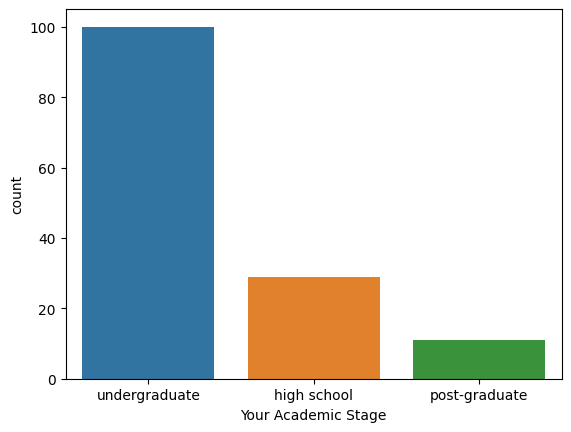

In [11]:
sns.countplot(x=df["Your Academic Stage"])
plt.show()

In [12]:
df.groupby("Rate your academic stress index ")["Your Academic Stage"].value_counts()

Rate your academic stress index   Your Academic Stage
1                                 undergraduate           4
                                  high school             2
2                                 undergraduate           8
                                  high school             1
3                                 undergraduate          26
                                  high school             6
                                  post-graduate           4
4                                 undergraduate          39
                                  high school            11
                                  post-graduate           6
5                                 undergraduate          23
                                  high school             9
                                  post-graduate           1
Name: count, dtype: int64

## Aqui, codificamos a coluna "Seu Estágio Acadêmico" com o OneHotEncoder. O OneHotEncoder cria uma coluna separada para cada categoria. Dessa forma, o modelo vê cada categoria de forma igual e independente.

In [ ]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore") # sparse_output=False retorna um array numpy.
# handle_unknown="ignore" não gera erro mesmo se uma nova categoria que nunca foi vista no conjunto de teste for introduzida.

In [14]:
encoded = ohe.fit_transform(df[["Your Academic Stage"]]) # Sütunu encode etme

In [15]:
encoded_cols = ohe.get_feature_names_out(["Your Academic Stage"]) # Feature isimlerini alma

In [16]:
df_encoded = pd.DataFrame(encoded, columns=encoded_cols, index=df.index) # Dataframe'e ekleme
df_guncel = pd.concat([df.drop("Your Academic Stage", axis=1), df_encoded], axis=1) # Orijinal dataframe ile birleştirme 

In [17]:
df_guncel.head()

,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index,Your Academic Stage_high school,Your Academic Stage_post-graduate,Your Academic Stage_undergraduate
0,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5,0.0,0.0,1.0
1,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3,0.0,0.0,1.0
2,1,1,Peaceful,"Social support (friends, family)",No,2,4,0.0,0.0,1.0
3,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3,0.0,0.0,1.0
4,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5,0.0,0.0,1.0


In [18]:
df_guncel.columns

Index(['Peer pressure', 'Academic pressure from your home',
       'Study Environment', 'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index ', 'Your Academic Stage_high school',
       'Your Academic Stage_post-graduate',
       'Your Academic Stage_undergraduate'],
      dtype='object')

In [19]:
df_guncel["Study Environment"].value_counts()

Study Environment
Peaceful     69
disrupted    38
Noisy        32
Name: count, dtype: int64

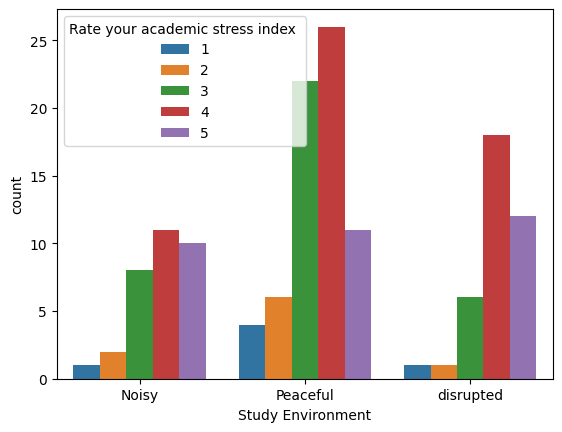

In [20]:
sns.countplot(x="Study Environment",data=df_guncel,hue="Rate your academic stress index ")
plt.show()

## Study Environment sütununda 1 tane boş değer (nan) var , veri seti küçük olduğu için boş değer olan satırı silmek yerine en çok görülen değerle doldurma (mode imputation) yolunu tercih ettim.

In [21]:
df_guncel["Study Environment"].isnull().sum()

1

In [22]:
most_common = df_guncel["Study Environment"].mode()[0]

In [23]:
df_guncel["Study Environment"] = df_guncel["Study Environment"].fillna(most_common)

In [24]:
df_guncel["Study Environment"].isnull().sum()

0

In [25]:
df_guncel["Study Environment"].unique()

array(['Noisy', 'Peaceful', 'disrupted'], dtype=object)

## Como a coluna Ambiente de Estudo pode assumir 3 valores diferentes, assim como a coluna Seu Estágio Acadêmico, apliquei o OneHotEncoder novamente.

In [26]:
encoded = ohe.fit_transform(df_guncel[["Study Environment"]])

In [27]:
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["Study Environment"])) # Yeni sütun isimlerini alma

In [28]:
df = pd.concat([df_guncel.drop("Study Environment", axis=1), encoded_df], axis=1) # Eski sütunu atıp yenisini ekleme

In [29]:
df.head()

,Peer pressure,Academic pressure from your home,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index,Your Academic Stage_high school,Your Academic Stage_post-graduate,Your Academic Stage_undergraduate,Study Environment_Noisy,Study Environment_Peaceful,Study Environment_disrupted
0,4,5,Analyze the situation and handle it with intel...,No,3,5,0.0,0.0,1.0,1.0,0.0,0.0
1,3,4,Analyze the situation and handle it with intel...,No,3,3,0.0,0.0,1.0,0.0,1.0,0.0
2,1,1,"Social support (friends, family)",No,2,4,0.0,0.0,1.0,0.0,1.0,0.0
3,3,2,Analyze the situation and handle it with intel...,No,4,3,0.0,0.0,1.0,0.0,1.0,0.0
4,3,3,Analyze the situation and handle it with intel...,No,4,5,0.0,0.0,1.0,0.0,1.0,0.0


In [30]:
df["What coping strategy you use as a student?"].value_counts()

What coping strategy you use as a student?
Analyze the situation and handle it with intellect    87
Emotional breakdown (crying a lot)                    32
Social support (friends, family)                      21
Name: count, dtype: int64

In [31]:
df.groupby("Rate your academic stress index ")["What coping strategy you use as a student?"].value_counts()

Rate your academic stress index   What coping strategy you use as a student?        
1                                 Analyze the situation and handle it with intellect     4
                                  Emotional breakdown (crying a lot)                     1
                                  Social support (friends, family)                       1
2                                 Analyze the situation and handle it with intellect     5
                                  Emotional breakdown (crying a lot)                     3
                                  Social support (friends, family)                       1
3                                 Analyze the situation and handle it with intellect    24
                                  Emotional breakdown (crying a lot)                     6
                                  Social support (friends, family)                       6
4                                 Analyze the situation and handle it with intellect    39
     

In [32]:
df["What coping strategy you use as a student?"].unique()

array(['Analyze the situation and handle it with intellect',
       'Social support (friends, family)',
       'Emotional breakdown (crying a lot)'], dtype=object)

## Como havia 3 respostas diferentes para a pergunta "Que tipo de estratégia você usa para lidar com o estresse como estudante?", eu a codifiquei com OneHotEncoder porque é uma variável categórica nominal e não ordenada.

In [33]:
encoded=ohe.fit_transform(df[["What coping strategy you use as a student?"]])

In [34]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(["What coping strategy you use as a student?"]))

In [35]:
df = pd.concat([df.drop("What coping strategy you use as a student?", axis=1), encoded_df], axis=1)

In [36]:
df.head()

,Peer pressure,Academic pressure from your home,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index,Your Academic Stage_high school,Your Academic Stage_post-graduate,Your Academic Stage_undergraduate,Study Environment_Noisy,Study Environment_Peaceful,Study Environment_disrupted,What coping strategy you use as a student?_Analyze the situation and handle it with intellect,What coping strategy you use as a student?_Emotional breakdown (crying a lot),"What coping strategy you use as a student?_Social support (friends, family)"
0,4,5,No,3,5,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,3,4,No,3,3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,1,No,2,4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,3,2,No,4,3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,3,3,No,4,5,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [37]:
df["Do you have any bad habits like smoking, drinking on a daily basis?"].unique()

array(['No', 'prefer not to say', 'Yes'], dtype=object)

In [38]:
df["Do you have any bad habits like smoking, drinking on a daily basis?"].value_counts()

Do you have any bad habits like smoking, drinking on a daily basis?
No                   123
Yes                   10
prefer not to say      7
Name: count, dtype: int64

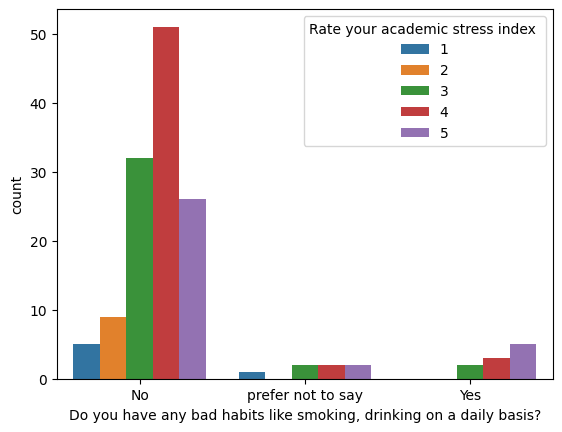

In [39]:
sns.countplot(x="Do you have any bad habits like smoking, drinking on a daily basis?",data=df,hue="Rate your academic stress index ")
plt.show()

## A coluna que determina se os alunos têm maus hábitos tem três valores: sim, não e prefiro não dizer. Aqui, usei a função pd.get_dummies(). get_dummies() cria uma coluna separada para cada categoria. Esta é uma solução prática, especialmente quando não queremos nos preocupar com operações adicionais de ajuste e transformação, como o OneHotEncoder. Pode ser implementada de forma rápida e fácil em pequenos conjuntos de dados.

In [40]:
df = pd.get_dummies(df,columns=["Do you have any bad habits like smoking, drinking on a daily basis?"],prefix="BadHabits")

In [41]:
df.columns

Index(['Peer pressure', 'Academic pressure from your home',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index ', 'Your Academic Stage_high school',
       'Your Academic Stage_post-graduate',
       'Your Academic Stage_undergraduate', 'Study Environment_Noisy',
       'Study Environment_Peaceful', 'Study Environment_disrupted',
       'What coping strategy you use as a student?_Analyze the situation and handle it with intellect',
       'What coping strategy you use as a student?_Emotional breakdown (crying a lot)',
       'What coping strategy you use as a student?_Social support (friends, family)',
       'BadHabits_No', 'BadHabits_Yes', 'BadHabits_prefer not to say'],
      dtype='object')

In [42]:
df.head()

,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index,Your Academic Stage_high school,Your Academic Stage_post-graduate,Your Academic Stage_undergraduate,Study Environment_Noisy,Study Environment_Peaceful,Study Environment_disrupted,What coping strategy you use as a student?_Analyze the situation and handle it with intellect,What coping strategy you use as a student?_Emotional breakdown (crying a lot),"What coping strategy you use as a student?_Social support (friends, family)",BadHabits_No,BadHabits_Yes,BadHabits_prefer not to say
0,4,5,3,5,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,True,False,False
1,3,4,3,3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,True,False,False
2,1,1,2,4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,False
3,3,2,4,3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,True,False,False
4,3,3,4,5,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,True,False,False
